SAMAGRA GUPTA 590014891 AIML B12

In [1]:
import numpy as np                                                              # Name : Aruansh Khare | SAP ID: 590012991 | Batch 11
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred)
print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 1.0


In [4]:
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

In [5]:
cov_matrix = np.dot(X_centered.T, X_centered) / (X_centered.shape[0] - 1)

In [6]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [7]:
idx = np.argsort(eigenvalues)[::-1]
principal_vector = eigenvectors[:, idx[0]]

In [8]:
X_pca = np.dot(X_centered, principal_vector.reshape(-1,1))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

pca_acc = accuracy_score(y_test, y_pred)

print("PCA Accuracy:", pca_acc)

PCA Accuracy: 0.9111111111111111


In [10]:
classes = np.unique(y)

mean_vectors = []
for c in classes:
    mean_vectors.append(np.mean(X[y==c], axis=0))

In [11]:
SW = np.zeros((4,4))

for c, mv in zip(classes, mean_vectors):
    class_scatter = np.zeros((4,4))

    for row in X[y==c]:
        row = row.reshape(4,1)
        mv = mv.reshape(4,1)
        class_scatter += (row-mv).dot((row-mv).T)

    SW += class_scatter

In [12]:
mean_overall = np.mean(X, axis=0).reshape(4,1)

SB = np.zeros((4,4))

for i, mean_vec in enumerate(mean_vectors):

    n = X[y==i].shape[0]
    mean_vec = mean_vec.reshape(4,1)

    SB += n * (mean_vec - mean_overall).dot((mean_vec - mean_overall).T)

In [13]:
A = np.linalg.inv(SW).dot(SB)

eigenvalues, eigenvectors = np.linalg.eig(A)

In [14]:
idx = np.argsort(abs(eigenvalues))[::-1]

lda_vector = eigenvectors[:, idx[0]]

In [15]:
X_lda = np.dot(X, lda_vector.reshape(-1,1))

In [19]:
X_lda = np.real(X_lda)
X_train, X_test, y_train, y_test = train_test_split(X_lda, y, test_size=0.3)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

lda_acc = accuracy_score(y_test, y_pred)

print("LDA Accuracy:", lda_acc)

LDA Accuracy: 0.9555555555555556


In [20]:
print("Baseline Accuracy:", baseline_acc)
print("PCA Accuracy:", pca_acc)
print("LDA Accuracy:", lda_acc)

Baseline Accuracy: 1.0
PCA Accuracy: 0.9111111111111111
LDA Accuracy: 0.9555555555555556


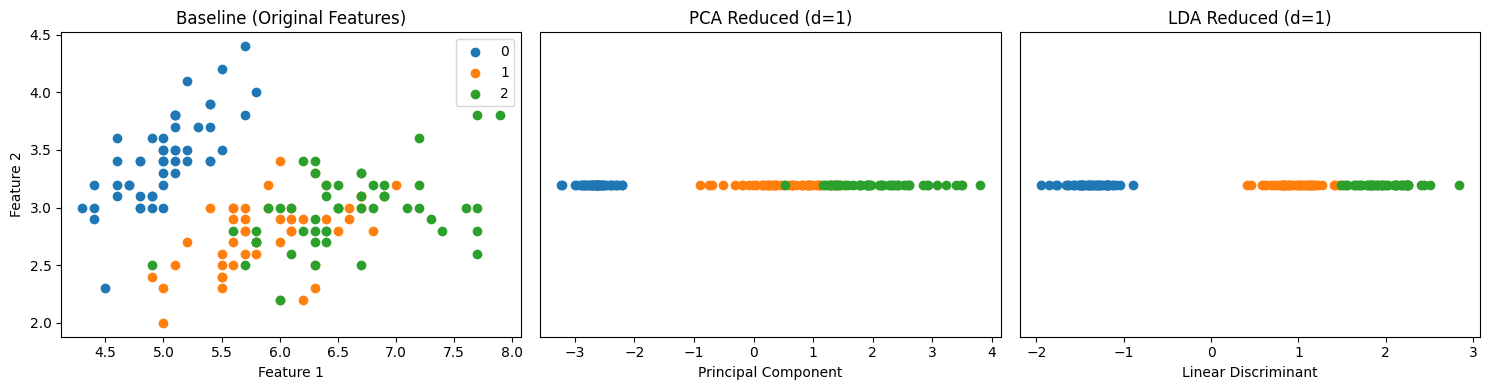

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

# ---------------- Baseline ----------------
plt.subplot(1,3,1)
for i in np.unique(y):
    plt.scatter(X[y==i,0], X[y==i,1], label=i)

plt.title("Baseline (Original Features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()


# ---------------- PCA ----------------
plt.subplot(1,3,2)
for i in np.unique(y):
    plt.scatter(X_pca[y==i], np.zeros_like(X_pca[y==i]), label=i)

plt.title("PCA Reduced (d=1)")
plt.xlabel("Principal Component")
plt.yticks([])


# ---------------- LDA ----------------
plt.subplot(1,3,3)
for i in np.unique(y):
    plt.scatter(X_lda[y==i], np.zeros_like(X_lda[y==i]), label=i)

plt.title("LDA Reduced (d=1)")
plt.xlabel("Linear Discriminant")
plt.yticks([])

plt.tight_layout()
plt.show()